# Access USGS stream gauge data

This code snippets demonstrates how to access data from the US Geological Survey (USGS)'s stream gauge network in the U.S. using the USGS `dataretrieval` library.

The library [page](https://doi-usgs.github.io/dataretrieval-python/) and [GitHub page](https://github.com/DOI-USGS/dataretrieval-python) provide comprehensive documentation for a range of data access options, including obtaining data for a single gauge or multiple gauges within a catchment area, and more. To see the entire range of data access options, visit the [demos](https://github.com/DOI-USGS/dataretrieval-python/tree/main/demos) page.

Before using the library, the documentation suggests setting up an API key for access to the Water Data API at this [link](https://api.waterdata.usgs.gov/signup/).

You can also browse the daily gauge data [here](https://api.waterdata.usgs.gov/ogcapi/v0/collections/daily/items?limit=2000).

#### Acknowledgements

Thanks to SARP 2026 student **Cree Taylor** for finding the `dataretrieval` library and contributing the snippet idea!

## Setup

In [1]:
%pip install dataretrieval

  Using cached dataretrieval-1.2.0-py3-none-any.whl.metadata (12 kB)
Using cached dataretrieval-1.2.0-py3-none-any.whl (164 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Water API key
import os
# os.environ["API_USGS_PAT"] = "your_api_key_here"
os.environ["API_USGS_PAT"] = "taxq5CRCNyEG98Bgbon0rUhYvJHMtAPnEZHXqJEO"

In [3]:
from dataretrieval import waterdata
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

## Find parameter codes using the reference table
* Search for certain variables of interest to obtain the parameter code (also searchable [here](https://waterdata.usgs.gov/code-dictionary/)
* List of parameter codes: https://api.waterdata.usgs.gov/ogcapi/v0/collections/parameter-codes/items
* List of statistic codes: https://api.waterdata.usgs.gov/ogcapi/v0/collections/statistic-codes/items
* `get_reference_table`: https://doi-usgs.github.io/dataretrieval-python/reference/waterdata.html#dataretrieval.waterdata.get_reference_table

In [4]:
# Get reference table containing codes
param_codes = waterdata.get_reference_table(collection='parameter-codes')[0]
print(f'Reference table has {len(param_codes)} rows\nShowing first 10 rows:')
param_codes.sort_values('parameter_code').head(10)

Retrieving: parameter-codes · 1 page · 19,617 rows · 999/1,000 requests remaining


Reference table has 19617 rows
Showing first 10 rows:


,parameter_code,parameter_name,unit_of_measure,parameter_group_code,parameter_description,medium,statistical_basis,time_basis,weight_basis,particle_size_basis,sample_fraction,temperature_basis,epa_equivalence
0,00001,"Xsec loc, US from rb",ft,INF,"Location in cross section, distance from right...",None,None,None,None,None,None,None,Agree
1,00002,"Xsec loc, US from rb",%,INF,"Location in cross section, distance from right...",None,None,None,None,None,None,None,Agree
2,00003,Sampling depth,ft,INF,"Sampling depth, feet",None,None,None,None,None,None,None,Agree
3,00004,Stream width,ft,PHY,"Stream width, feet",None,None,None,None,None,None,None,Agree
4,00005,"Loctn in X-sec,depth",%,INF,"Location in cross section, fraction of total d...",None,None,None,None,None,Total,None,Agree
5,00008,Sample accnt. number,nu,INF,Sample accounting number,None,None,None,None,None,None,None,Agree
6,00009,"Xsec loc, DS from lb",ft,INF,"Location in cross section, distance from left ...",None,None,None,None,None,None,None,Agree
7,00010,"Temperature, water",deg C,PHY,"Temperature, water, degrees Celsius",Water,None,None,None,None,None,None,Agree
8,00011,"Temperature, water",deg F,PHY,"Temperature, water, degrees Fahrenheit",Water,None,None,None,None,None,None,Agree
9,00012,"Temperature, evap pan, 48",deg C,PHY,"Evaporation temperature, 48-inch pan, degrees ...",None,None,None,None,None,None,None,Agree


In [5]:
# Find the param code for a variable of interest
search_term = 'discharge' # try 'temperature'
param_codes_match_search = param_codes[param_codes['parameter_name'].str.contains(search_term, case=False)]
print(f'{len(param_codes_match_search)} rows match search term\nShowing first 5 rows:')
param_codes_match_search.head(5)

23 rows match search term
Showing first 5 rows:


,parameter_code,parameter_name,unit_of_measure,parameter_group_code,parameter_description,medium,statistical_basis,time_basis,weight_basis,particle_size_basis,sample_fraction,temperature_basis,epa_equivalence
42,00060,Discharge,ft3/s,PHY,"Discharge, cubic feet per second",Water,Mean,1 Day,None,None,None,None,Not checked
43,00061,"Discharge, instant.",ft3/s,PHY,"Discharge, instantaneous, cubic feet per second",Water,None,None,None,None,None,None,Agree
769,04122,"Bedload discharge, daily mean",ton/d/ft,SED,"Bedload sediment discharge, daily mean, per un...",Sediment,Mean,Daily,None,None,Bedload,None,Agree
1701,30208,Discharge,m3/sec,PHY,"Discharge, cubic meters per second",Water,Mean,1 Day,None,None,None,None,Agree
1702,30209,Instantaneous Discharge,m3/sec,PHY,"Discharge, instantaneous, cubic meters per second",Water,None,None,None,None,None,None,Agree


## Find monitoring locations
* Search the available monitoring locations - by state, county, bbox, etc.
* Can also browse locations [here](https://api.waterdata.usgs.gov/ogcapi/v0/collections/daily/items?limit=2000) (change the max limit per page to ensure you get all relevant results)
* `get_monitoring_locations`: https://doi-usgs.github.io/dataretrieval-python/reference/waterdata.html#dataretrieval.waterdata.get_monitoring_locations

In [14]:
# Get info about the monitoring locations
# We can provide a state, county, or bounding box
monitoring_locs, monitoring_locs_metadata = waterdata.get_monitoring_locations(
                                                            state='California',  # full name, postal code ('MD'), or FIPS ('24')
                                                            county_name='Yuba County',
                                                            # bbox = [xmin, xmax, ymin, ymax]
                                                            site_type_code='ST'  # Stream sites
                                                            )

print(f"Found {len(monitoring_locs)} stream monitoring locations in California\nShowing first 5 locations:")
monitoring_locs.head(5)

Retrieving: monitoring-locations · 1 page · 66 rows · 995/1,000 requests remaining


Found 66 stream monitoring locations in California
Showing first 5 locations:


,monitoring_location_id,geometry,agency_code,agency_name,monitoring_location_number,monitoring_location_name,district_code,country_code,country_name,state_code,...,construction_date,aquifer_code,national_aquifer_code,aquifer_type_code,well_constructed_depth,hole_constructed_depth,depth_source_code,revision_note,revision_created,revision_modified
0,USGS-11395300,POINT (-121.08968 39.61795),USGS,U.S. Geological Survey,11395300,LOST C AB SLY C RES CA,06,US,United States of America,06,...,NaT,None,None,None,NaN,NaN,None,None,None,None
1,USGS-11407501,POINT (-121.61191 39.15878),USGS,U.S. Geological Survey,11407501,ADJUSTED FLOW S HONCUT C CA,06,US,United States of America,06,...,NaT,None,None,None,NaN,NaN,None,None,None,None
2,USGS-11407700,POINT (-121.6058 39.13878),USGS,U.S. Geological Survey,11407700,FEATHER R A YUBA CITY CA,06,US,United States of America,06,...,NaT,None,None,None,NaN,NaN,None,None,None,None
3,USGS-11409300,POINT (-121.04634 39.446),USGS,U.S. Geological Survey,11409300,OREGON C A CAMPTONVILLE CA,06,US,United States of America,06,...,NaT,None,None,None,NaN,NaN,None,None,None,None
4,USGS-11409350,POINT (-121.0594 39.44017),USGS,U.S. Geological Survey,11409350,CAMPTONVILLE TU A IT NR CAMPTONVILLE CA,06,US,United States of America,06,...,NaT,None,None,None,NaN,NaN,None,None,None,None


<Axes: >

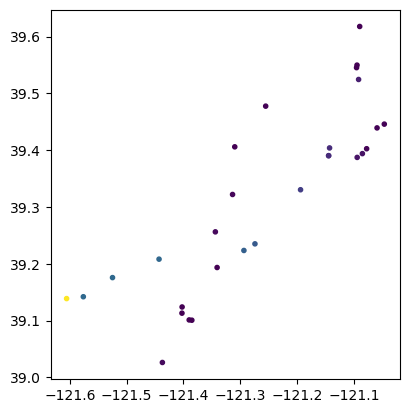

In [41]:
# The monitoring locations search returns a geodataframe wihch we can easily plot 
# Here colored by size of their drainage area
monitoring_locs.plot(marker='.', column='drainage_area')

In [65]:
# Search the returned locations based on a specific address location to match the monitoring location name
search_name = 'YUBA R NR MARYSVILLE'
matching_locs = monitoring_locs[monitoring_locs['monitoring_location_name'].str.contains(search_name, case=False)]
print(f"Found {len(matching_locs)} stream monitoring locations matching the search: {matching_locs['monitoring_location_id'].values}")
matching_locs

Found 1 stream monitoring locations matching the search: ['USGS-11421000']


,monitoring_location_id,geometry,agency_code,agency_name,monitoring_location_number,monitoring_location_name,district_code,country_code,country_name,state_code,...,construction_date,aquifer_code,national_aquifer_code,aquifer_type_code,well_constructed_depth,hole_constructed_depth,depth_source_code,revision_note,revision_created,revision_modified
32,USGS-11421000,POINT (-121.52496 39.17573),USGS,U.S. Geological Survey,11421000,YUBA R NR MARYSVILLE CA,06,US,United States of America,06,...,NaT,None,None,None,NaN,NaN,None,WSP 1715: 1956 (instantaneous maximum discharg...,2017-11-13T06:00:00+00:00,None


## Check data availabiliy
* For a location, check the start and end dates of the data and the variables available
* `get_combined_metadata`: https://doi-usgs.github.io/dataretrieval-python/reference/waterdata.html#dataretrieval.waterdata.get_combined_metadata

In [66]:
ts_available, _ = waterdata.get_combined_metadata(
    monitoring_location_id="USGS-11421000", # can provide one or more loc ids
    parameter_code=["00060", "00010"], # can provide one or more param codes
)
cols = ["parameter_name", "statistic_id", "begin", "end", "last_modified"]
ts_available[cols]

Retrieving: combined-metadata · 1 page · 6 rows · 977/1,000 requests remaining


,parameter_name,statistic_id,begin,end,last_modified
0,Discharge,None,1944-03-04 07:00:00+00:00,2025-02-05 08:00:00+00:00,2026-03-03 19:56:57.922484+00:00
1,Discharge,None,1987-09-11 17:20:00+00:00,2026-06-23 17:55:09+00:00,2026-07-11 02:39:31.539603+00:00
2,"Temperature, water",00001,1964-10-01 07:00:00+00:00,2003-09-29 07:00:00+00:00,2017-10-15 03:15:07.106463+00:00
3,"Temperature, water",00002,1964-10-01 07:00:00+00:00,2003-09-29 07:00:00+00:00,2017-04-04 05:04:07.140214+00:00
4,Discharge,00011,1987-10-01 14:15:00+00:00,2026-07-17 13:30:00+00:00,2026-07-17 06:41:18.415571+00:00
5,Discharge,00003,1943-10-01 07:00:00+00:00,2026-07-15 07:00:00+00:00,2026-07-17 08:40:36.729625+00:00


## Data access

In [68]:
# Define parameters for the search
loc_id = 'USGS-11421000'
param_code = '00060' # Discharge
start_date = '2023-01-01'
end_date = '2025-12-31'
# statistic_id = '00001' # Max daily # Defaults to '00003' mean daily

In [69]:
# Get daily streamflow data (returns DataFrame and metadata)
data, metadata = waterdata.get_daily(
                    monitoring_location_id=loc_id,
                    parameter_code=param_code,  
                    time=f'{start_date}/{end_date}')

print(f"Retrieved {len(data)} records")
print(f"Site: {data['monitoring_location_id'].iloc[0]}")
print(f"Mean discharge: {data['value'].mean():.2f} {data['unit_of_measure'].iloc[0]}")

# Show first few lines of data
data.head(5)

Retrieving: daily · 1 page · 1,096 rows · 978/1,000 requests remaining


Retrieved 1096 records
Site: USGS-11421000
Mean discharge: 2883.31 ft^3/s


,geometry,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,daily_id
0,POINT (-121.52496 39.17573),e4a078f99eb947d591ae94ea04698364,USGS-11421000,00060,00003,2023-01-01,17400,ft^3/s,Approved,None,2025-03-10 22:56:47.952777+00:00,3c69d2d3-2315-451b-9c35-d7f14db691c4
1,POINT (-121.52496 39.17573),e4a078f99eb947d591ae94ea04698364,USGS-11421000,00060,00003,2023-01-02,6530,ft^3/s,Approved,None,2025-03-10 22:56:47.952777+00:00,6fd1f2ee-3b4b-4d75-a641-632cda249cb0
2,POINT (-121.52496 39.17573),e4a078f99eb947d591ae94ea04698364,USGS-11421000,00060,00003,2023-01-03,5530,ft^3/s,Approved,None,2025-03-10 22:56:47.952777+00:00,7ce3322d-4935-412d-ab2a-7bcf351aa362
3,POINT (-121.52496 39.17573),e4a078f99eb947d591ae94ea04698364,USGS-11421000,00060,00003,2023-01-04,4970,ft^3/s,Approved,None,2025-03-10 22:56:47.952777+00:00,7cf5f74a-068b-4b9d-a3d2-9ac5cc845f3e
4,POINT (-121.52496 39.17573),e4a078f99eb947d591ae94ea04698364,USGS-11421000,00060,00003,2023-01-05,9300,ft^3/s,Approved,None,2025-03-10 22:56:47.952777+00:00,9a8d5c1c-b189-4e4a-b4e1-08cd287053cb


In [75]:
# Follow the metadata link to visit the web browser showing the location and info about the monitoring site
metadata

BaseMetadata(url=https://api.waterdata.usgs.gov/ogcapi/v0/collections/daily/items?monitoring_location_id=USGS-11421000&parameter_code=00060&time=2023-01-01%2F2025-12-31&limit=50000)

In [76]:
# Set time as the index and remove columns except for the discharge column
data = data[['time', 'value']].set_index('time').rename(columns={'value':'Discharge (ft^3/s)'})
data.head(5)

,Discharge (ft^3/s)
time,
2023-01-01,17400
2023-01-02,6530
2023-01-03,5530
2023-01-04,4970
2023-01-05,9300


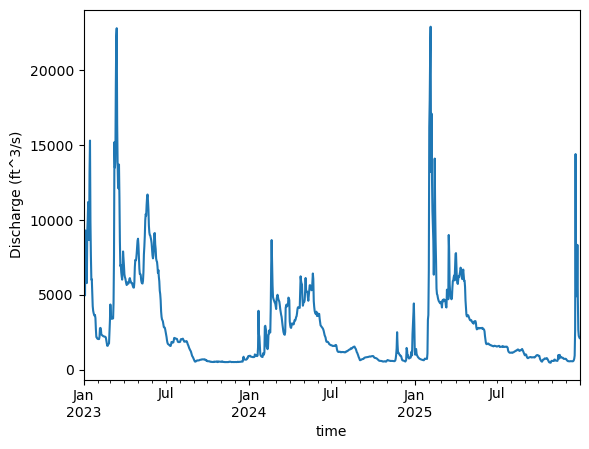

In [73]:
# Quick plot
fig, ax = plt.subplots()
data.plot(ax=ax)
ax.set_ylabel(data.columns[0])
ax.legend().set_visible(False)
plt.show()